# Ejercicio 1: Evaluación de solicitud de crédito bancario

### Ficha PEAS
| Elemento | Descripción |
| :--- | :--- |
| **P (Performance / Desempeño)** | Maximizar la colocación de créditos rentables y minimizar la tasa de morosidad/incumplimiento financiero. |
| **E (Environment / Entorno)** | Sistema bancario transaccional, base de datos crediticia de solicitantes y mercado financiero. |
| **A (Actuators / Acciones)** | Emitir decisión: "aprobar", "aprobar con condiciones", o "rechazar" la solicitud. |
| **S (Sensors / Percepciones)** | Datos de entrada: `ingreso_mensual` (soles), `monto_solicitado` (soles) y `tiene_historial_moroso` (booleano). |
| **Objetivo** | Determinar de forma autónoma la viabilidad del crédito mitigando el riesgo de impago. |

### Justificación de las reglas
Las reglas priorizan la solvencia financiera: un cliente con historial moroso representa un riesgo crítico y se rechaza si solicita más de una fracción moderada de su sueldo (relación > 0.3), admitiéndose con condiciones solo ante montos mínimos. Para clientes sin morosidad, relaciones bajas (<= 0.4) garantizan capacidad de pago inmediata (aprobación directa), mientras que relaciones medias (0.4 a 0.8) demandan garantías adicionales (aprobación con condiciones) para proteger la liquidez del banco. Si el monto solicitado supera el 80% de los ingresos, el endeudamiento es insostenible y se rechaza directamente.

In [1]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    """
    Agente de evaluación crediticia basado en reglas de capacidad de endeudamiento e historial.
    Retorna: (accion, motivo)
    """
    if ingreso_mensual <= 0:
        return "rechazar", "ingreso mensual no valido o igual a cero"
        
    relacion = monto_solicitado / ingreso_mensual
    
    if tiene_historial_moroso:
        if relacion <= 0.3:
            return "aprobar con condiciones", f"monto bajo (relacion {relacion:.2f}), pero requiere aval por morosidad previa"
        else:
            return "rechazar", f"relacion monto/ingreso de {relacion:.2f} riesgosa con historial moroso"
    else:
        if relacion <= 0.4:
            return "aprobar", f"capacidad de pago optima con relacion monto/ingreso de {relacion:.2f}"
        elif relacion <= 0.8:
            return "aprobar con condiciones", f"endeudamiento moderado (relacion {relacion:.2f}), requiere garantia adicional"
        else:
            return "rechazar", f"sobreendeudamiento critico con relacion monto/ingreso de {relacion:.2f}"

In [2]:
casos_prueba = [
    (5000, 1500, False),  # Relacion 0.30 -> Aprobar
    (5000, 2000, False),  # Relacion 0.40 (Caso borde exacto) -> Aprobar
    (5000, 3000, False),  # Relacion 0.60 -> Aprobar con condiciones
    (5000, 4000, False),  # Relacion 0.80 (Caso borde exacto) -> Aprobar con condiciones
    (5000, 5000, False),  # Relacion 1.00 -> Rechazar
    (4000, 1000, True),   # Relacion 0.25 moroso -> Aprobar con condiciones
    (4000, 2500, True)    # Relacion 0.625 moroso -> Rechazar
]

print(f"{'Ingreso':<10} | {'Monto':<10} | {'Moroso':<8} | {'Acción':<24} | {'Motivo'}")
print("-" * 90)
for ingreso, monto, moroso in casos_prueba:
    accion, motivo = agente_credito(ingreso, monto, moroso)
    print(f"S/ {ingreso:<7} | S/ {monto:<7} | {str(moroso):<8} | {accion:<24} | {motivo}")

Ingreso    | Monto      | Moroso   | Acción                   | Motivo
------------------------------------------------------------------------------------------
S/ 5000    | S/ 1500    | False    | aprobar                  | capacidad de pago optima con relacion monto/ingreso de 0.30
S/ 5000    | S/ 2000    | False    | aprobar                  | capacidad de pago optima con relacion monto/ingreso de 0.40
S/ 5000    | S/ 3000    | False    | aprobar con condiciones  | endeudamiento moderado (relacion 0.60), requiere garantia adicional
S/ 5000    | S/ 4000    | False    | aprobar con condiciones  | endeudamiento moderado (relacion 0.80), requiere garantia adicional
S/ 5000    | S/ 5000    | False    | rechazar                 | sobreendeudamiento critico con relacion monto/ingreso de 1.00
S/ 4000    | S/ 1000    | True     | aprobar con condiciones  | monto bajo (relacion 0.25), pero requiere aval por morosidad previa
S/ 4000    | S/ 2500    | True     | rechazar                 | rela

### Visualización

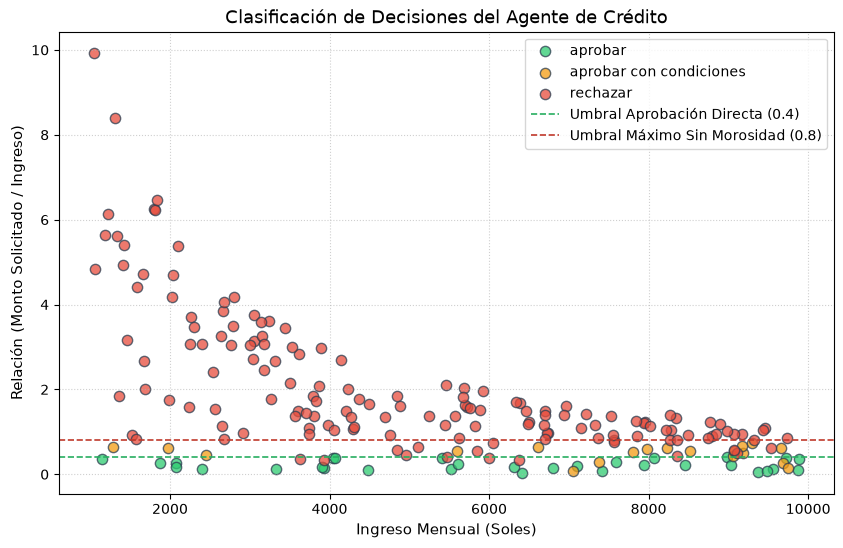

In [3]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)
n_solicitudes = 200

ingresos = np.random.uniform(1000, 10000, n_solicitudes)
montos = np.random.uniform(200, 12000, n_solicitudes)
historiales = np.random.choice([True, False], size=n_solicitudes, p=[0.3, 0.7])

relaciones = montos / ingresos
acciones = []

for ing, mon, mor in zip(ingresos, montos, historiales):
    acc, _ = agente_credito(ing, mon, mor)
    acciones.append(acc)

acciones = np.array(acciones)

plt.figure(figsize=(10, 6))
mapa_colores = {
    "aprobar": "#2ecc71",
    "aprobar con condiciones": "#f39c12",
    "rechazar": "#e74c3c"
}

for decision, color in mapa_colores.items():
    filtro = acciones == decision
    plt.scatter(
        ingresos[filtro],
        relaciones[filtro],
        c=color,
        label=decision,
        alpha=0.75,
        edgecolors='#2c3e50',
        s=55
    )

plt.axhline(0.4, color='#27ae60', linestyle='--', linewidth=1.2, label='Umbral Aprobación Directa (0.4)')
plt.axhline(0.8, color='#c0392b', linestyle='--', linewidth=1.2, label='Umbral Máximo Sin Morosidad (0.8)')
plt.title("Clasificación de Decisiones del Agente de Crédito", fontsize=13)
plt.xlabel("Ingreso Mensual (Soles)", fontsize=11)
plt.ylabel("Relación (Monto Solicitado / Ingreso)", fontsize=11)
plt.legend(loc="upper right")
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()